# Evaluation
- Verifier auf drei verschiedenen Anzahlen an positiven test samples trainieren und auswerten
- Dabei wird auf test samples von anderen gegriffen und der santa barbara corpus test ausgeführt
- Zukünftig auch auf viel mehr syntetischen Daten

In [ ]:
!pip install openwakeword
!pip install onnxruntime

INFO: pip is looking at multiple versions of openwakeword to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 81.3 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
from openwakeword.model import Model
import numpy as np
from google.colab import drive
import glob
import openwakeword
import openwakeword.metrics
import soundfile as sf
import librosa
import os

In [ ]:
# Connect google drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparation of data

In [ ]:
recordings_dir = "/content/drive/MyDrive/speech_interaction/recordings"
output_dir = "/content/drive/MyDrive/speech_interaction/recordings_converted"

# Find all recordings
all_wav_files = glob.glob(f"{recordings_dir}/**/*.wav", recursive=True)
print(f"Found: {len(all_wav_files)} files\n")

converted = 0
already_ok = 0

for filepath in all_wav_files:
    audio, sr = sf.read(filepath)

    # Rebuild folder structure
    relative_path = os.path.relpath(filepath, recordings_dir)
    output_path = os.path.join(output_dir, relative_path)
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    needs_conversion = sr != 16000 or audio.ndim > 1

    if needs_conversion:
        if audio.ndim > 1:
            audio = audio.mean(axis=1)
        if sr != 16000:
            audio = librosa.resample(audio.astype(np.float32), orig_sr=sr, target_sr=16000)
        audio_int16 = (audio * 32767).astype(np.int16)
        sf.write(output_path, audio_int16, 16000)
        print(f"✅ Converted: {relative_path}")
        converted += 1
    else:
        # Simple copy
        import shutil
        shutil.copy2(filepath, output_path)
        print(f"📋 Kopiert: {relative_path}")
        already_ok += 1

print(f"\nFinished! {converted} converted, {already_ok} copied.")
print(f"Saved in: {output_dir}")

Found: 51 files

📋 Kopiert: test/false/Lotte 2.wav
📋 Kopiert: test/false/Lotte 4.wav
📋 Kopiert: test/false/Lotte 1.wav
📋 Kopiert: test/false/Lotte 3.wav
📋 Kopiert: test/false/Marie 3.wav
📋 Kopiert: test/false/Marie 4.wav
📋 Kopiert: test/false/Marie 5.wav
📋 Kopiert: test/false/Lotte 5.wav
📋 Kopiert: test/false/Marie 2.wav
📋 Kopiert: test/false/Marie 1.wav
✅ Converted: test/false/Julia test 4.wav
✅ Converted: test/false/Julia test 5.wav
✅ Converted: test/false/Julia test 1.wav
✅ Converted: test/false/Julia test 2.wav
✅ Converted: test/false/Julia test 3.wav
✅ Converted: test/false/m_alex_test_5.wav
✅ Converted: test/false/m_alex_test_4.wav
✅ Converted: test/false/m_alex_test_3.wav
✅ Converted: test/false/m_alex_test_2.wav
✅ Converted: test/false/m_alex_test_1.wav
✅ Converted: test/false/m_felix_test_5.wav
✅ Converted: test/false/m_felix_test_4.wav
✅ Converted: test/false/m_felix_test_3.wav
✅ Converted: test/false/m_felix_test_2.wav
✅ Converted: test/false/m_felix_test_1.wav
📋 Kopiert: te

In [ ]:
# Connect to trainings data and find amount of audio data
base_path = "/content/drive/MyDrive/speech_interaction/recordings_converted/"

# Train clips
true_train_clips = glob.glob(f"{base_path}training/true/*.wav")
false_train_clips = glob.glob(f"{base_path}training/false/*.wav")

print(f"True train Clips found:, {len(true_train_clips)}")
print(true_train_clips)
print(f"False train Clips found:, {len(false_train_clips)}")
print(false_train_clips)

# Test clips

true_test_clips = glob.glob(f"{base_path}test/true/*.wav")
false_test_clips = glob.glob(f"{base_path}test/false/*.wav")

print(f"True test Clips found:, {len(true_test_clips)}")
print(true_test_clips)
print(f"False test Clips found:, {len(false_test_clips)}")
print(false_test_clips)

True train Clips found:, 10
['/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 5.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 3.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 9.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 2.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 1.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 8.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 6.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 4.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 7.wav', '/content/drive/MyDrive/speech_interaction/recordings_converted/training/true/Sophie 10.wav']
False train Clips found:, 11
['/content/

# See how a simple OpenWakeword model behaves

- The goal is to have a reference point on how a model provided by the library behaves compared to the model plus the verifier we train

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the Santa Barbara corpus


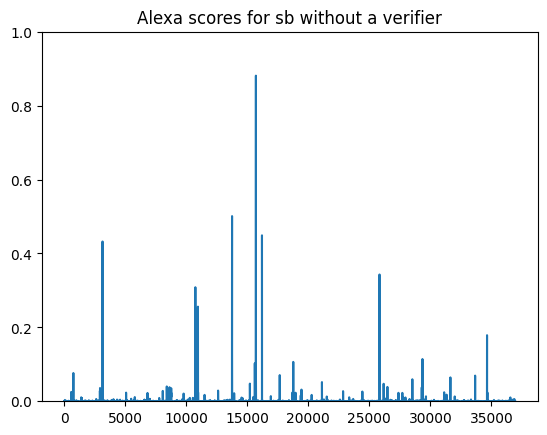

False-accept rate per hour: 4.87


In [ ]:
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

alexa_model = Model(wakeword_model_paths=[wakeword_alexa],)


# Saint Barbara
print("Running false-positive analysis on the Santa Barbara corpus")
sb_scores = alexa_model.predict_clip(sb_corpus_clip)


plt.figure()
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores])
_ = plt.ylim(0,1)
plt.show()
plt.close()


# Calculate the false-accept rate per hour from this new result

false_accepts = openwakeword.metrics.get_false_positives(
    [i["alexa"] for i in sb_scores], threshold=0.6
)

duration_sec = sf.info(sb_corpus_clip).duration
duration_hr = duration_sec / 3600

print(f"False-accept rate per hour: {false_accepts / duration_hr:.2f}")

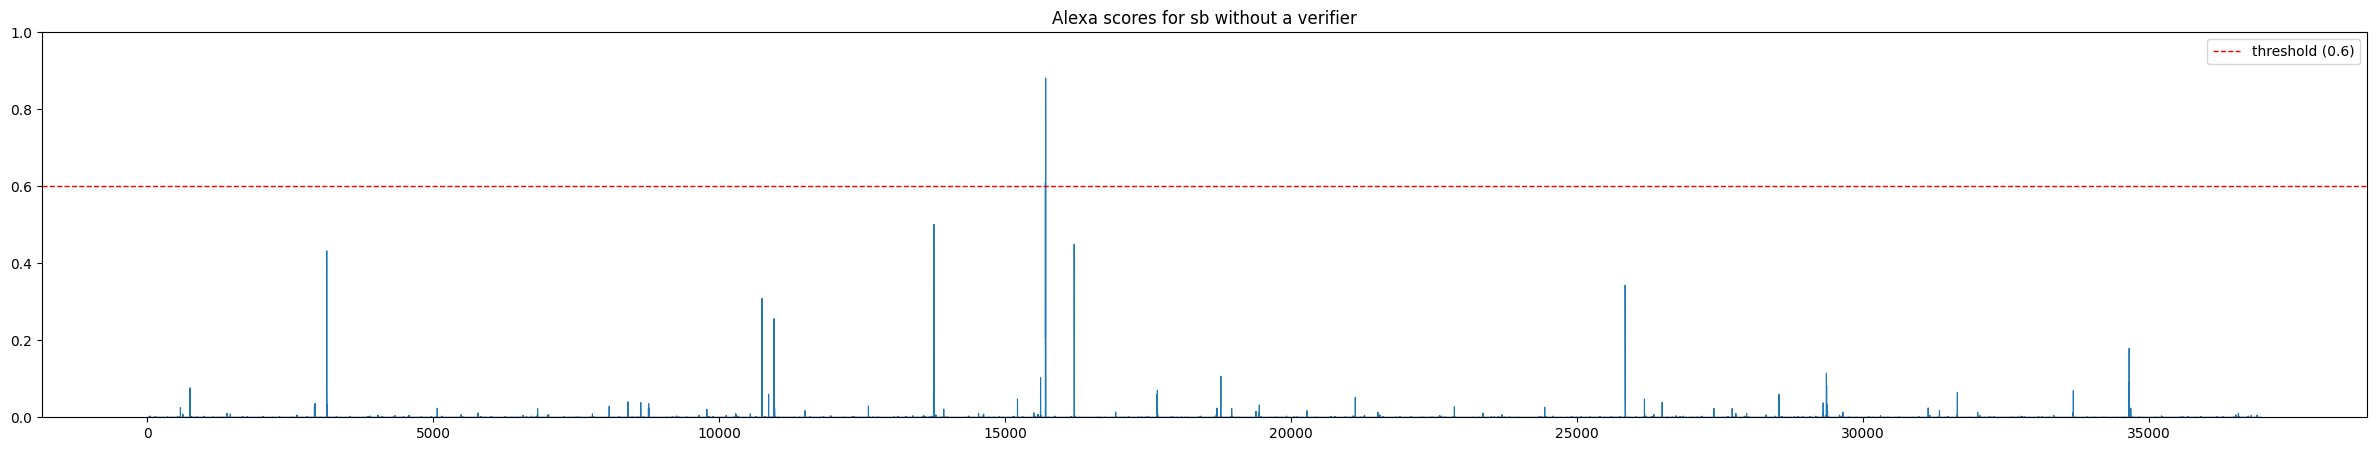

In [ ]:
plt.figure(figsize=(30, 5))  # much wider, modest height
plt.title("Alexa scores for sb without a verifier")
plt.plot([i["alexa"] for i in sb_scores], linewidth=0.8)
plt.axhline(0.6, color="red", linestyle="--", linewidth=1, label="threshold (0.6)")
plt.ylim(0, 1)
plt.legend()
plt.show()
plt.close()

In [ ]:
print(sf.info(sb_corpus_clip).duration)

2954.435625


In [ ]:
print(false_accepts, type(false_accepts))

4 <class 'numpy.int64'>


Evaluating the alexa model


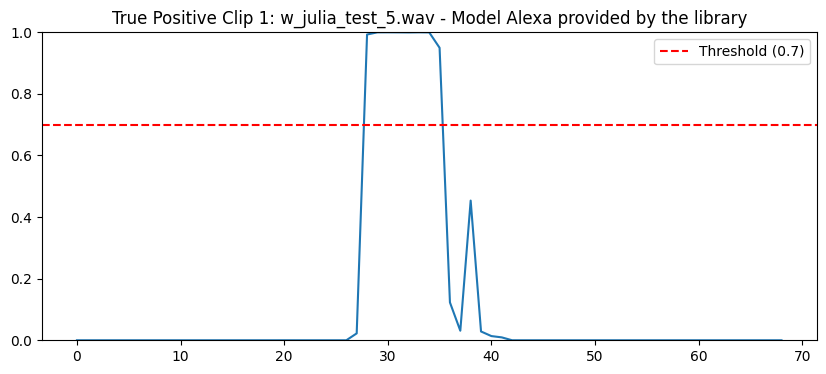

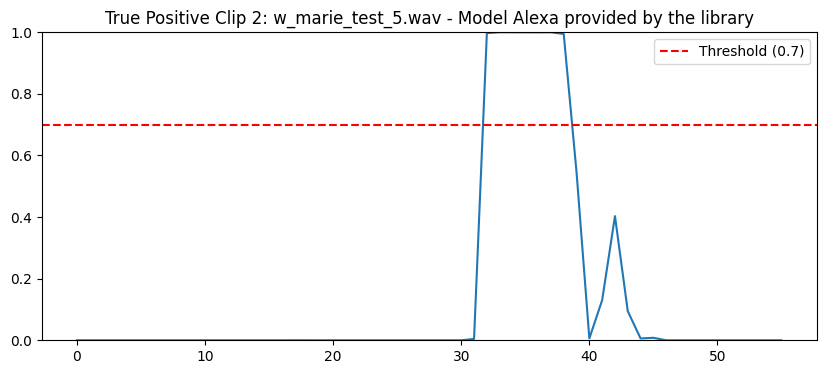

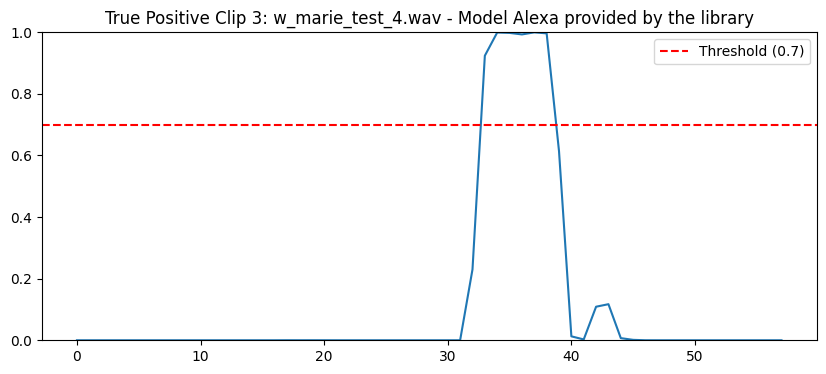

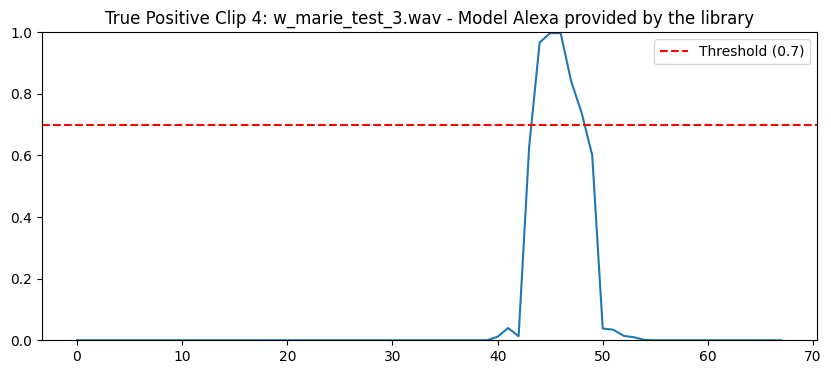

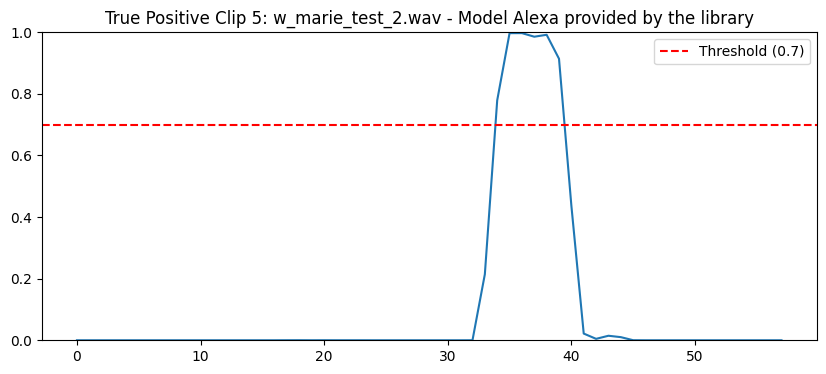

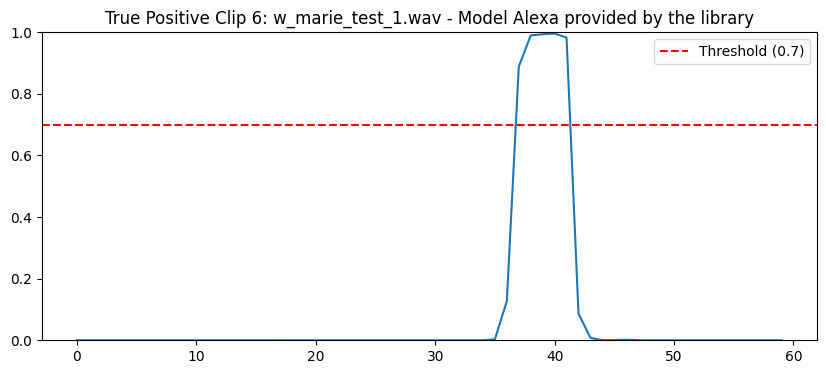

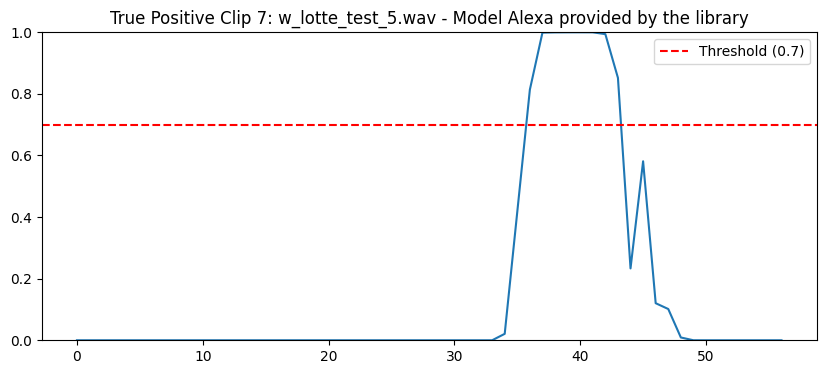

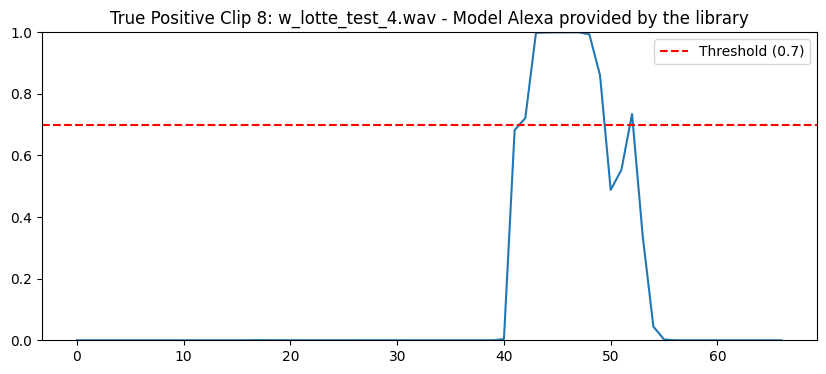

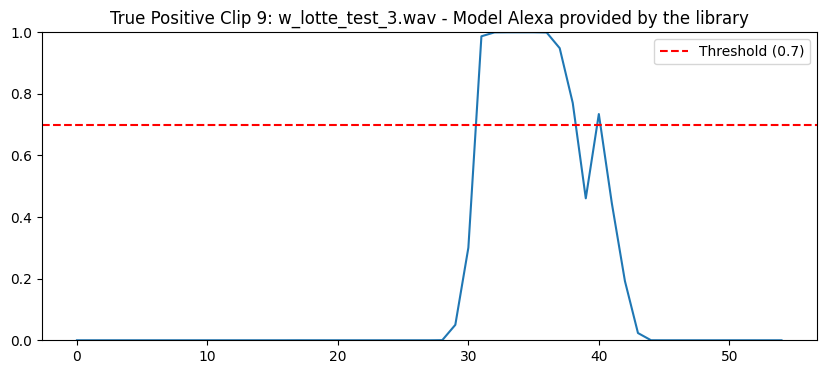

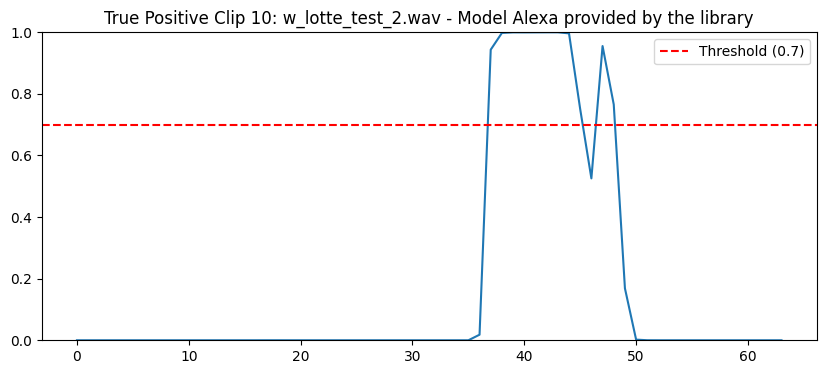

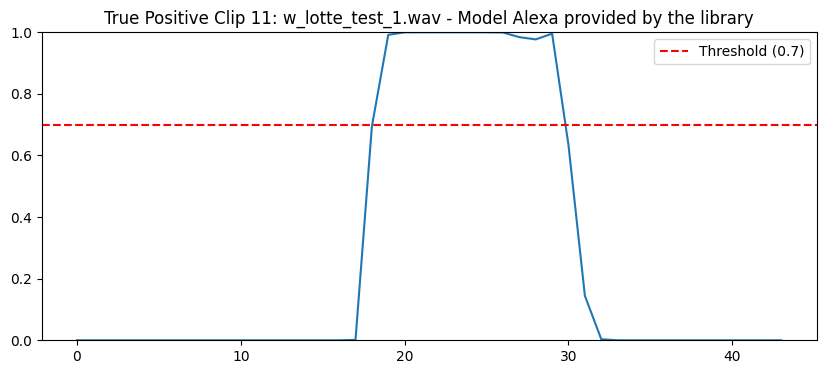

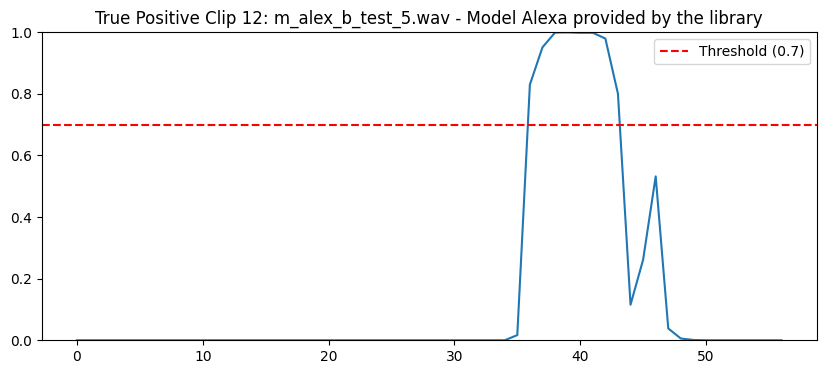

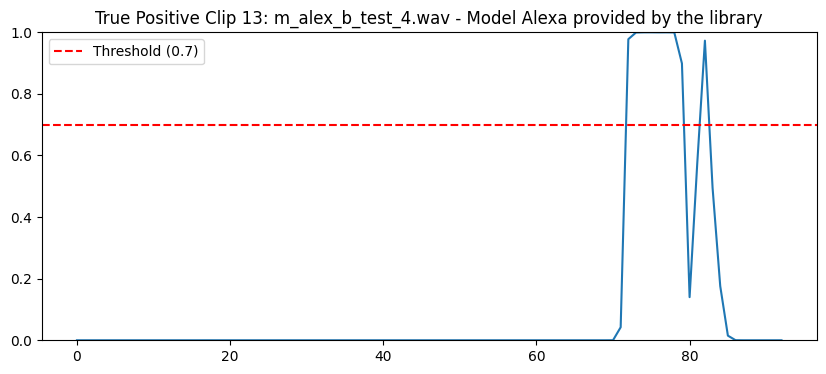

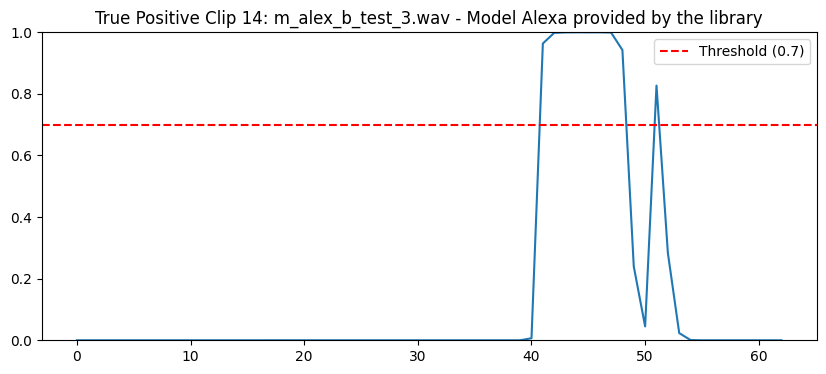

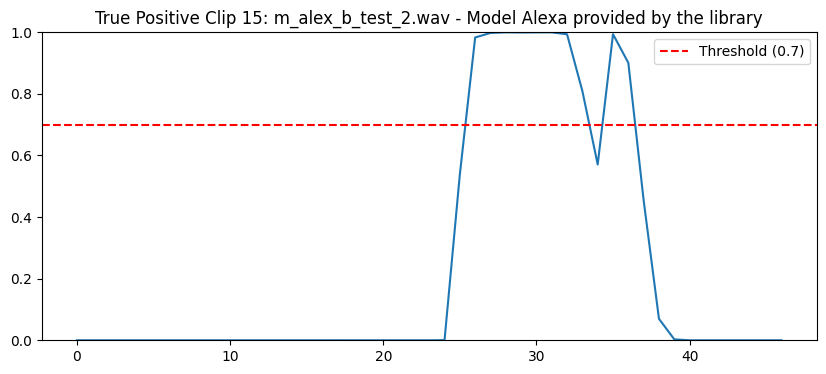

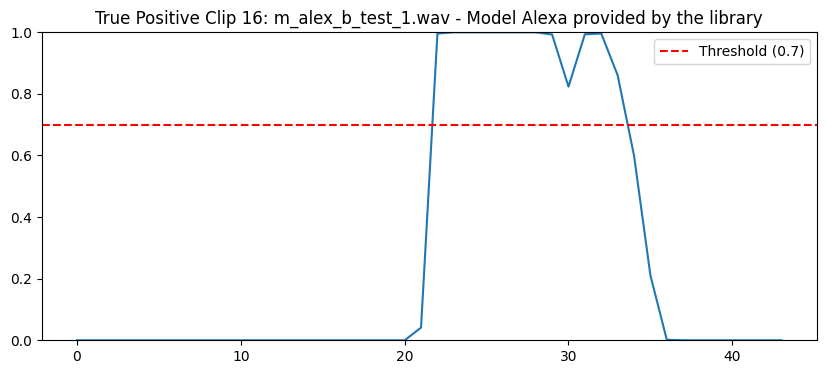

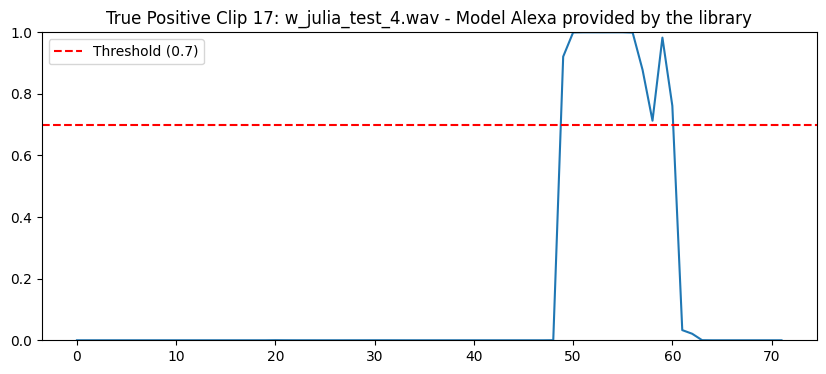

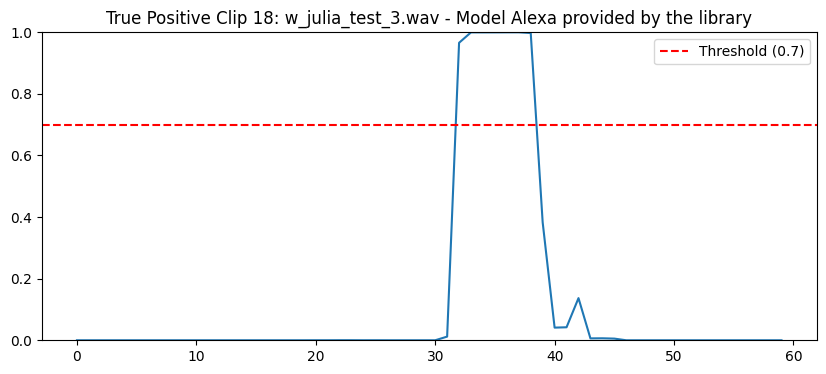

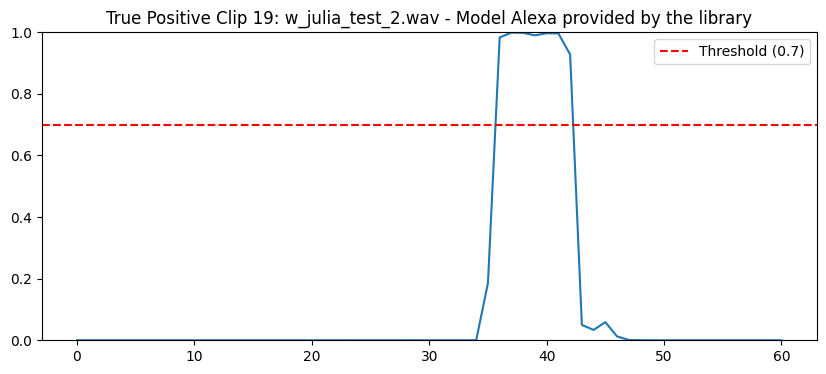

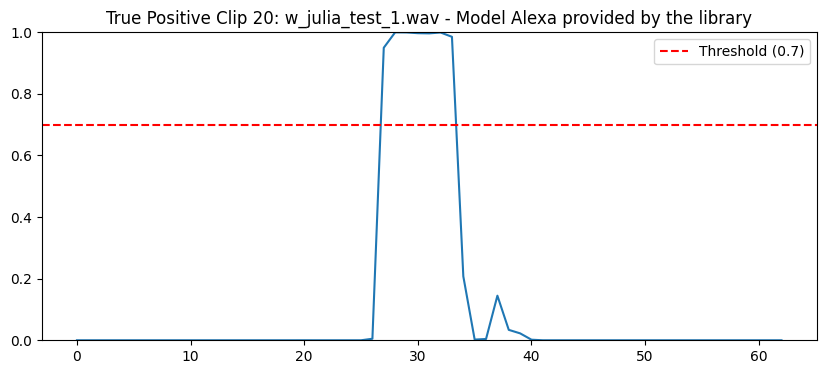

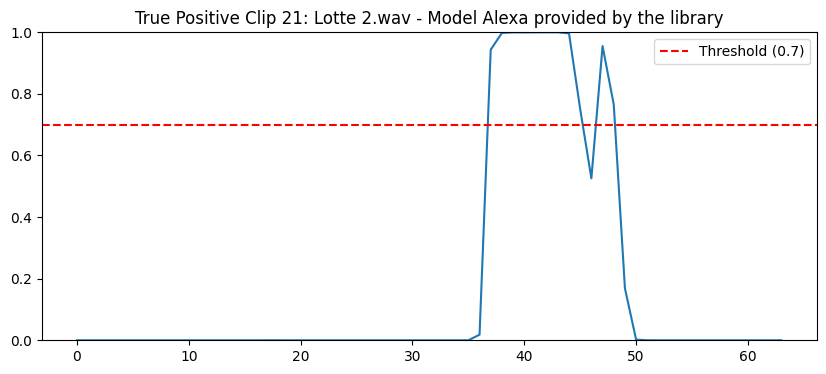

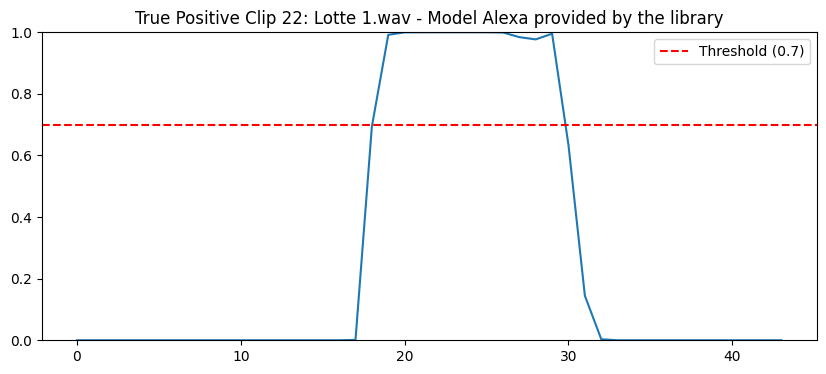

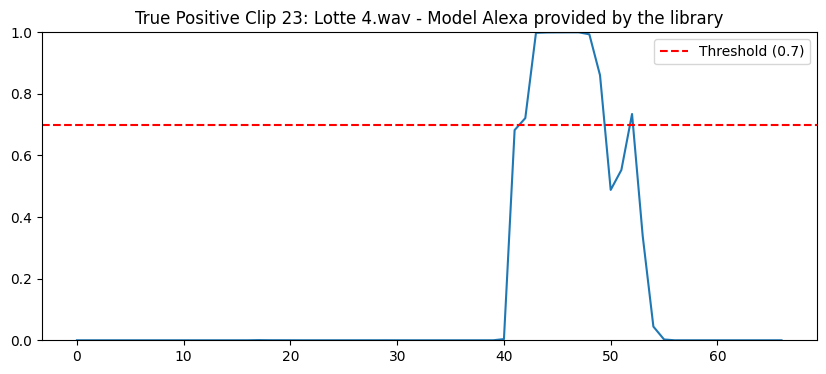

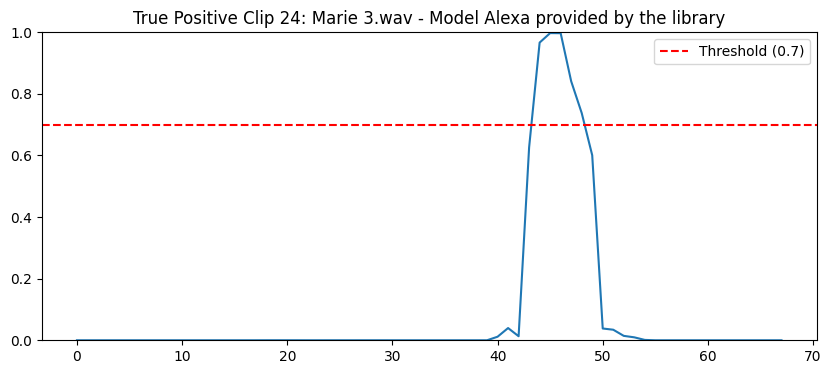

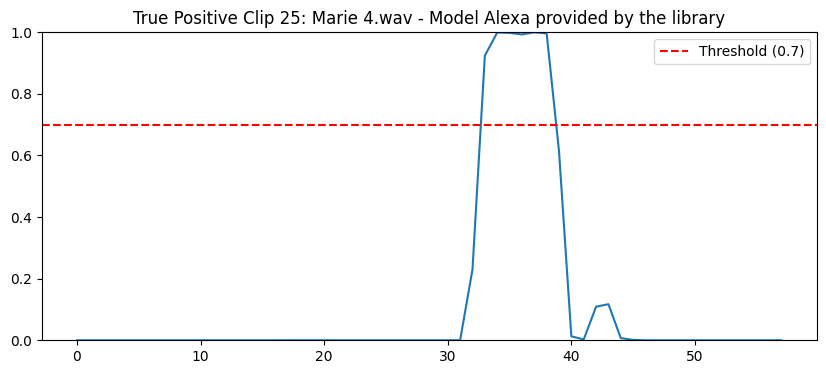

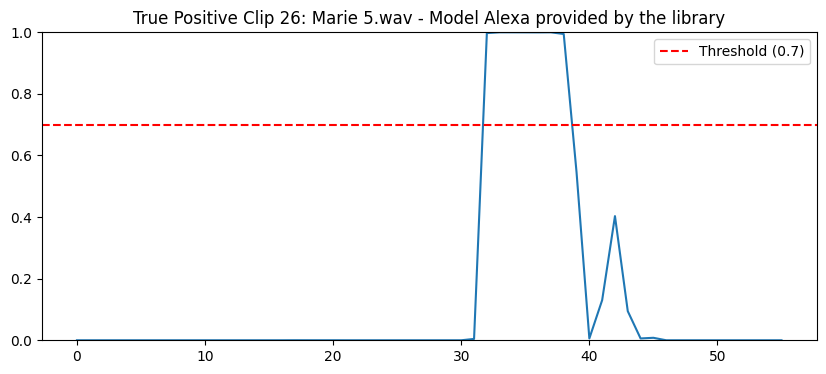

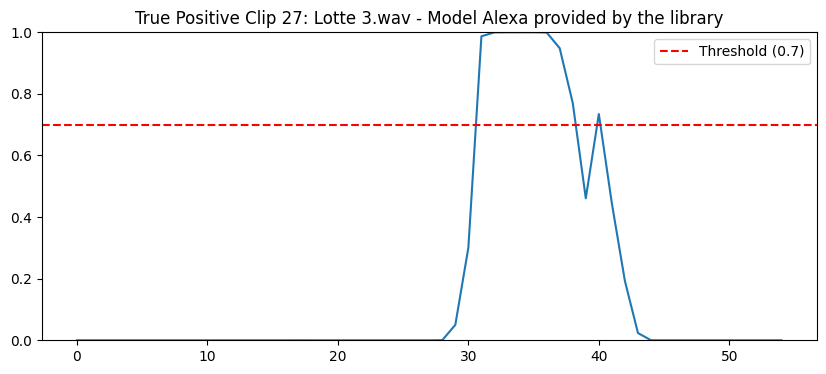

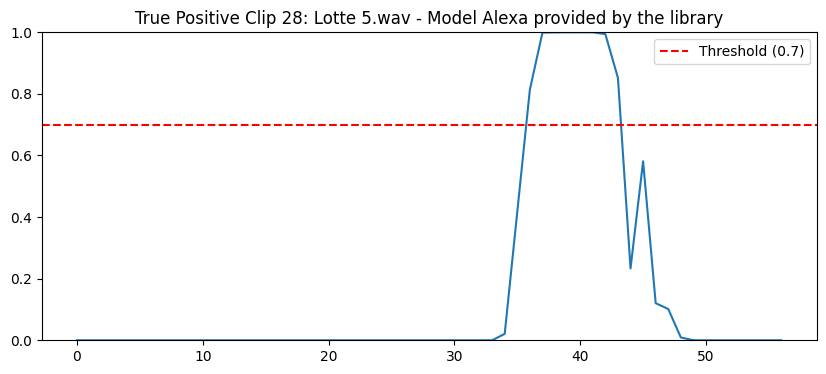

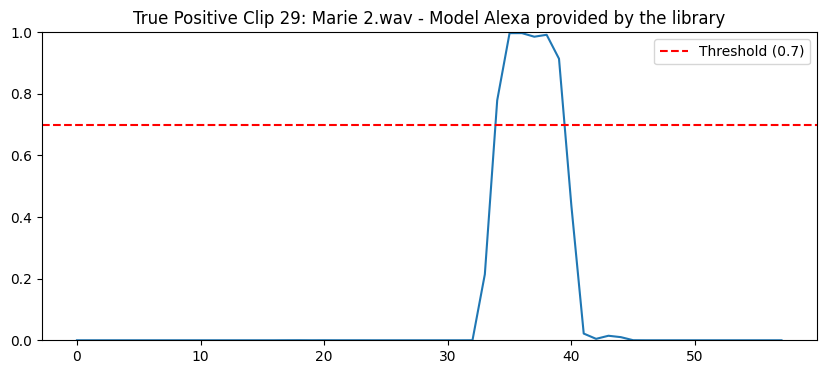

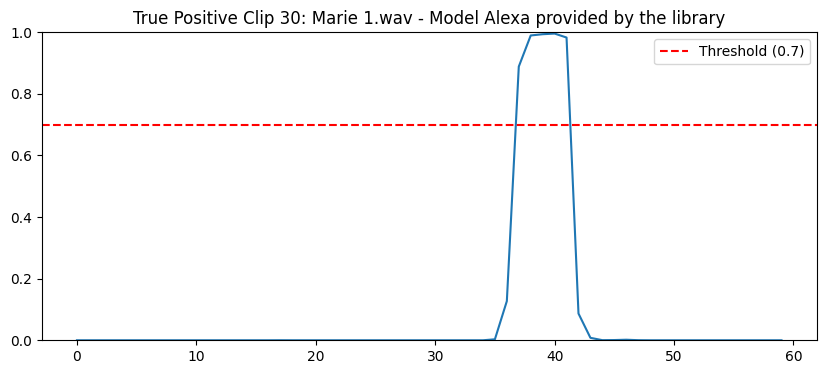

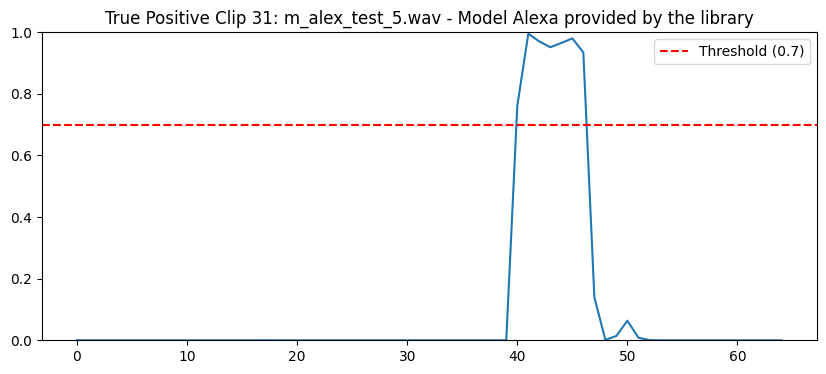

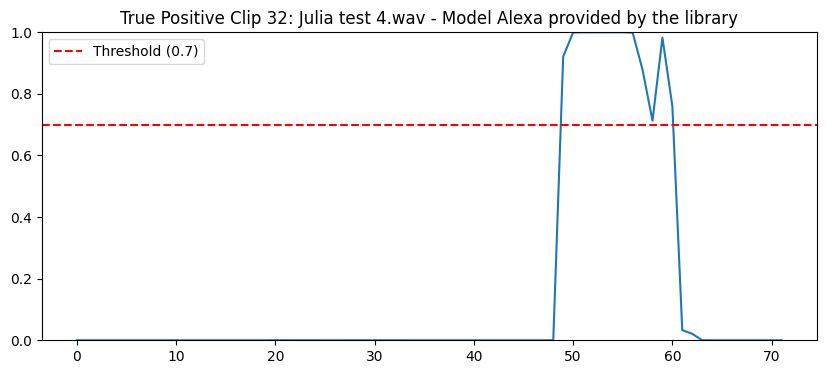

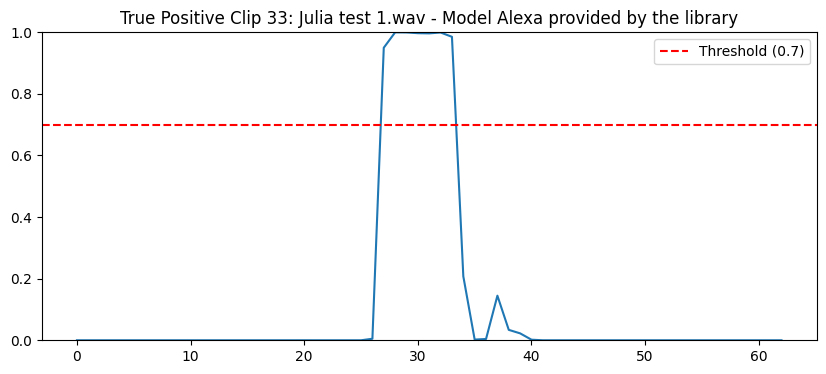

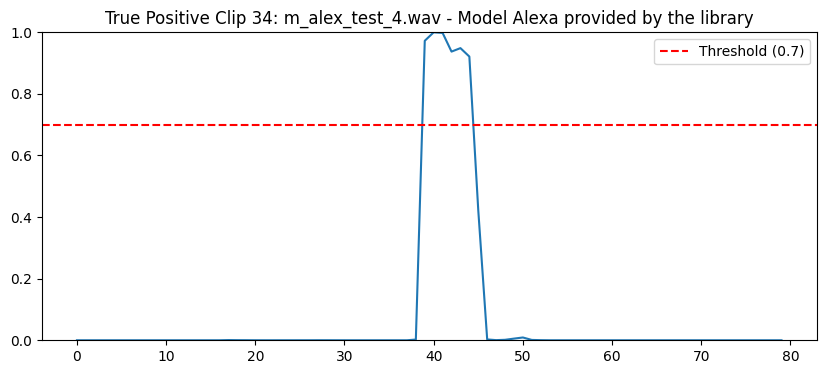

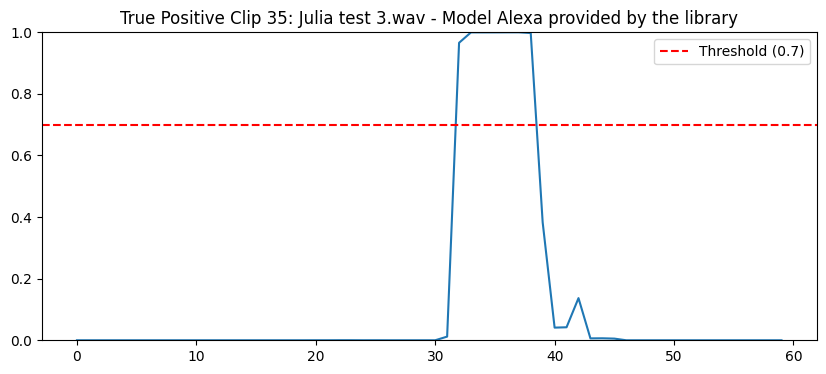

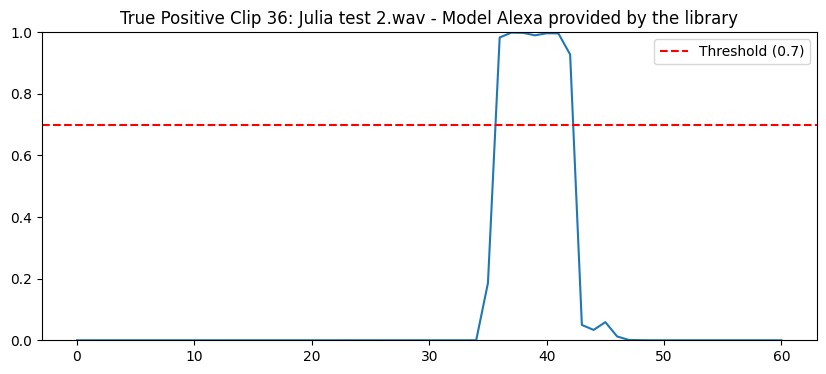

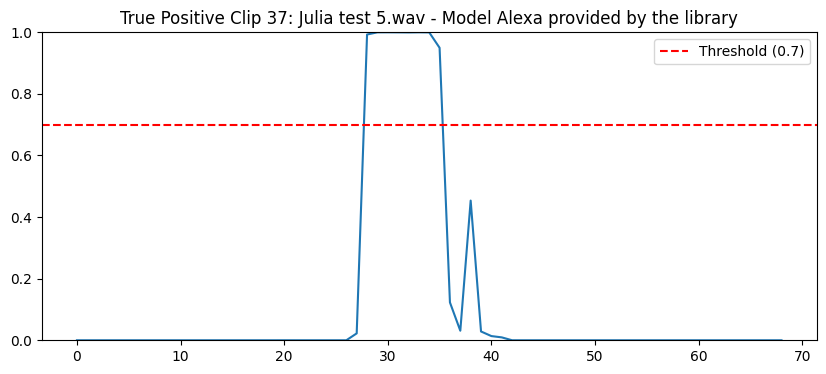

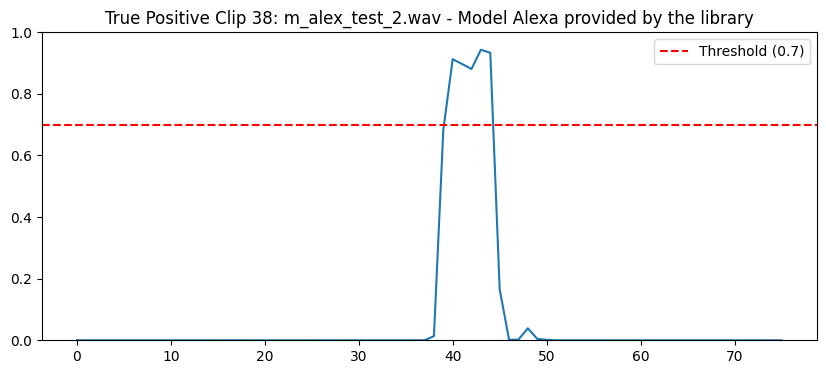

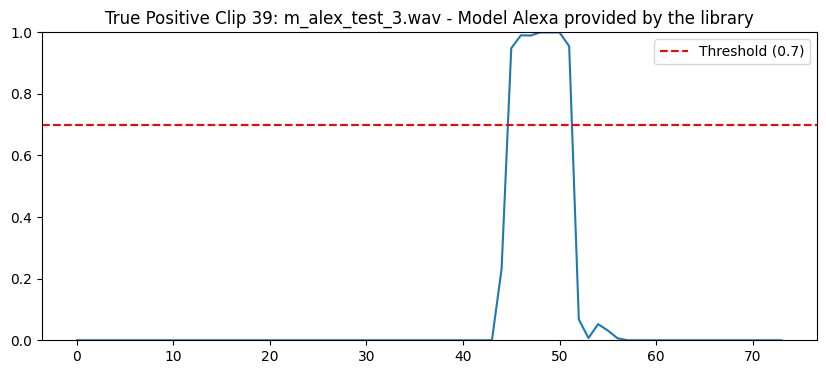

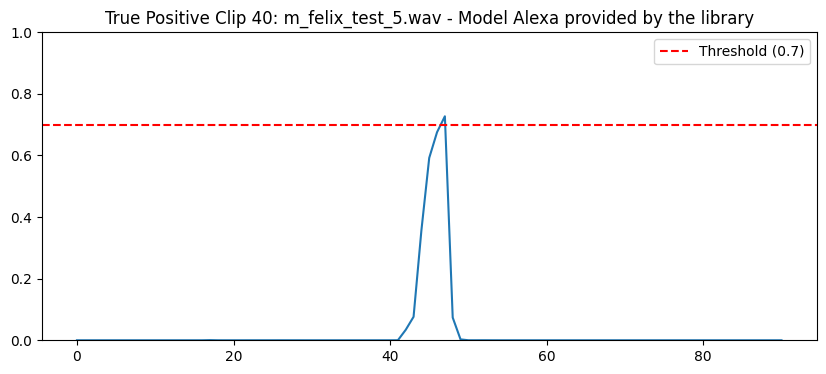

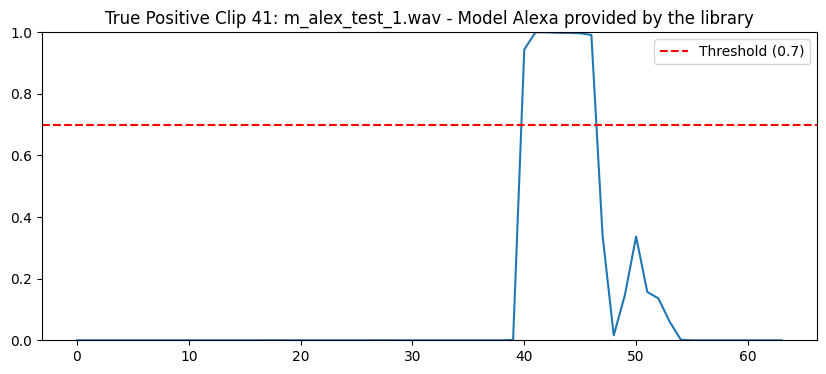

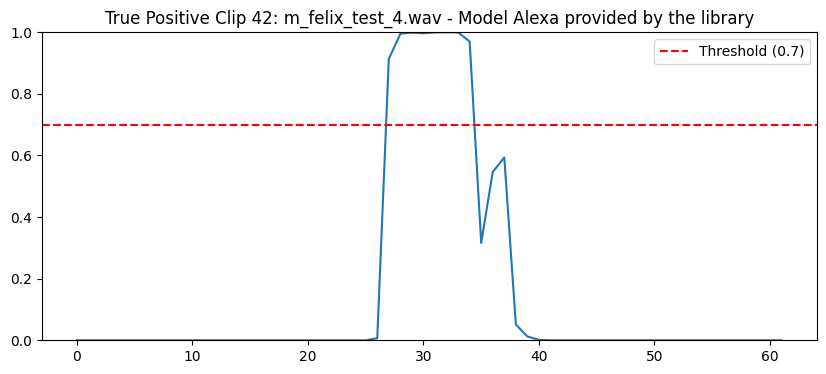

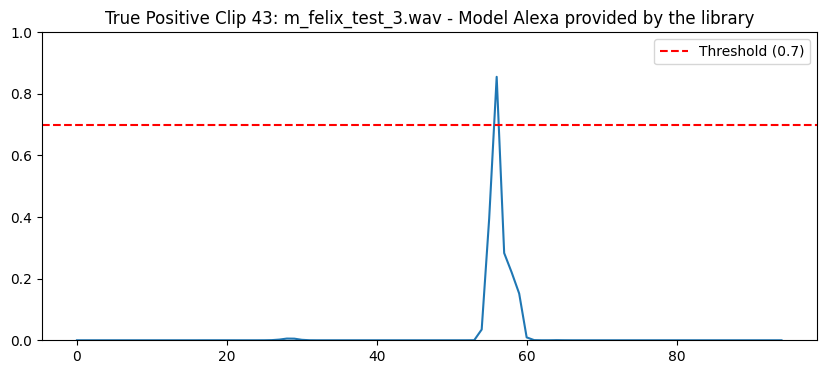

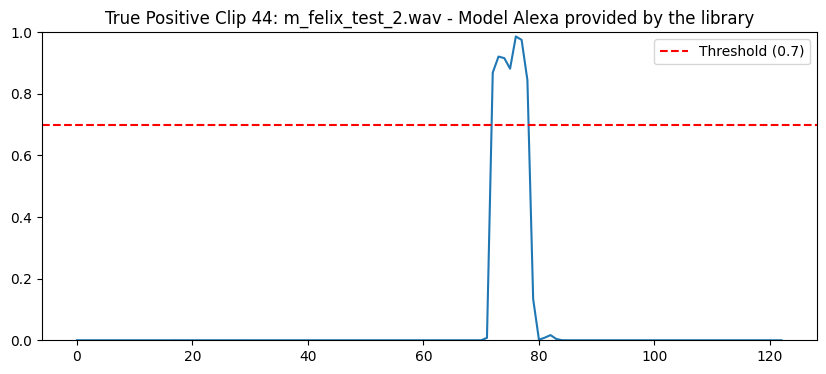

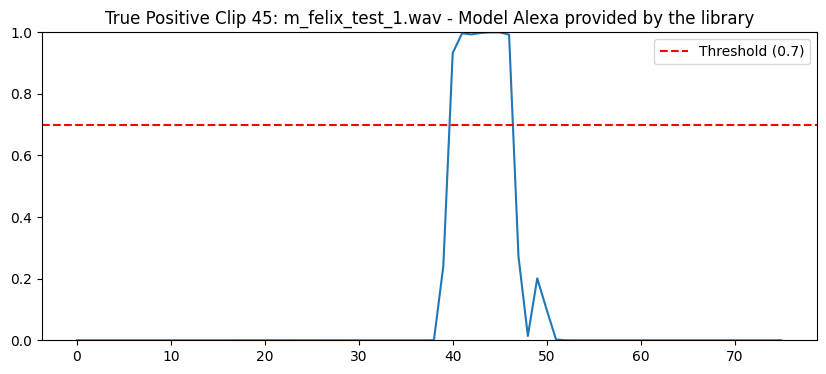


Results for model alexa':
True positive clips detected: 45 out of 45
Recall (True Acceptance Rate): 1.00


In [ ]:
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"


alexa_model = Model(wakeword_model_paths=[wakeword_alexa],)

true_positives_detected = 0
total_true_test_clips = len(false_test_clips)

print(f"Evaluating the alexa model")

for i, clip_path in enumerate(false_test_clips):
    scores_per_chunk = alexa_model.predict_clip(clip_path)
    alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

    # Check if there's any activation above the threshold in this clip
    if any(score > 0.7 for score in alexa_scores):
        true_positives_detected += 1

    # Optional: Plot for visual inspection (uncomment to see plots for each clip)
    plt.figure(figsize=(10, 4))
    plt.title(f"True Positive Clip {i+1}: {os.path.basename(clip_path)} - Model Alexa provided by the library")
    plt.plot(alexa_scores)
    plt.axhline(0.7, color='red', linestyle='--', label='Threshold (0.7)')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    plt.close()

print(f"\nResults for model alexa':")
print(f"True positive clips detected: {true_positives_detected} out of {total_true_test_clips}")
if total_true_test_clips > 0:
    recall = true_positives_detected / total_true_test_clips
    print(f"Recall (True Acceptance Rate): {recall:.2f}")
else:
    print("No true test clips to evaluate.")

# Evaluate the verifier

- In our example we wanted to test how the verifier behaves if we provide more positive example audios of the voice and keyword we trained the verifier for

## Further evaluations we did

- Check how it behaves with female and male voices
- See what the results are testing it on the santa barbara corpus test
- Using the results to make a decision on if we would use it as our own security feature for other software




In [ ]:
SAMPLE_SIZES = [3, 6, 10]
summary_results = {}
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

for n_pos in SAMPLE_SIZES:

    # 1. Slice the first n_pos positive clips
    positive_train_clips = true_train_clips[:n_pos]
    model_path = f"/content/drive/MyDrive/speech_interaction/verifier/verifier_{n_pos}pos.pkl"


    # 2. Train a separate verifier for this version
    openwakeword.train_custom_verifier(
        positive_reference_clips=positive_train_clips,
        negative_reference_clips=false_train_clips,
        output_path=model_path,
        model_name='alexa'
    )

    # 3. Load a fresh Model instance with this verifier
    verifier_model = Model(
        wakeword_model_paths=[wakeword_alexa],
        custom_verifier_models={'alexa': model_path},
        custom_verifier_threshold=0.7
    )

    total_false_activations_neg_set_for_current_n_pos = 0 # Initialize for false positives on negative set

    # 4. False-positive analysis on the negative test set
    print("Running false-positive analysis on the negative")
    for clip_path in false_test_clips:
        scores_per_chunk = verifier_model.predict_clip(clip_path)
        alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

        false_positives_clip = openwakeword.metrics.get_false_positives(
            alexa_scores, threshold=verifier_model.custom_verifier_threshold
        )
        total_false_activations_neg_set_for_current_n_pos += false_positives_clip

        # → per-clip score plot + activation count
        plt.figure()
        plt.title("Alexa scores for negative test: "  + str(n_pos))
        plt.plot(alexa_scores)
        _ = plt.ylim(0,1)
        plt.close() # Close figure after plotting

    # Todo test the positives
    print("Running false-positive analysis on the positive")
    for clip_path in true_test_clips:
        scores_per_chunk = verifier_model.predict_clip(clip_path)
        alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

        plt.figure()
        plt.title("Alexa scores for positve test on: "  + str(n_pos))
        plt.plot(alexa_scores)
        _ = plt.ylim(0,1)
        plt.close() # Close figure after plotting

    # TODO (diesen Step in einen eigenen CodeBlock ausbauen)Santa Barbara
    print("Running false-positive analysis on the Santa Barbara corpus")
    sb_scores = verifier_model.predict_clip(sb_corpus_clip)


    plt.figure()
    plt.title("Alexa scores for: "  + str(n_pos))
    plt.plot([i["alexa"] for i in sb_scores])
    _ = plt.ylim(0,1)
    plt.close() # Close figure after plotting


    # Calculate the false-accept rate per hour from this new result

    false_accepts = openwakeword.metrics.get_false_positives(
        [i["alexa"] for i in sb_scores], threshold=0.7
    )

    print(f"False-accept rate per hour: {false_accepts/1}")

    # 5. Santa Barbara Corpus — FAR per hour
    clip_duration_hours = len(sb_audio) / sb_sr / 3600
    far_per_hour = false_accepts / clip_duration_hours

    summary_results[n_pos] = {
        "total_false_activations_neg_set": total_false_activations_neg_set_for_current_n_pos,
        "false_accepts_sb": false_accepts,
        "far_per_hour": far_per_hour,
    }

Processing negative reference clips: 100%|██████████| 11/11 [00:04<00:00,  2.67it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the negative
Running false-positive analysis on the positive
Running false-positive analysis on the Santa Barbara corpus
False-accept rate per hour: 0.0


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
Processing negative reference clips: 100%|██████████| 11/11 [00:04<00:00,  2.25it/s]


Training and saving verifier model...
Done!


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:153: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Running false-positive analysis on the negative
Running false-positive analysis on the positive
Running false-positive analysis on the Santa Barbara corpus


### Evaluate the verifier using the santa barbara corpus test



In [ ]:
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"
sb_corpus_clip = "/content/drive/MyDrive/speech_interaction/evaluation/santa_barbara_corpus_test_clip.wav"
wakeword_alexa = "/content/drive/MyDrive/speech_interaction/models/alexa.onnx"

sb_audio, sb_sr = sf.read(sb_corpus_clip)

print("Running false-positive analysis on the Santa Barbara corpus")

for filename in os.listdir(model_path):
  print(f"\nEvaluating verifier: {filename}")
  if not filename.endswith(".pkl"):
    continue

  verifier_model = Model(
      wakeword_model_paths=[wakeword_alexa],
      custom_verifier_models={'alexa': model_path + filename},
      custom_verifier_threshold=0.7
  )

  sb_scores_list = [i["alexa"] for i in verifier_model.predict_clip(sb_corpus_clip)]

  # Print some statistics about the scores
  print(f"  Max score: {np.max(sb_scores_list):.4f}")
  print(f"  Mean score: {np.mean(sb_scores_list):.4f}")
  print(f"  Number of scores above 0.7: {np.sum(np.array(sb_scores_list) > 0.7)}")

  plt.figure()
  plt.title(f"Alexa scores for: {filename}")
  plt.axhline(0.7, color="red", linestyle="--", linewidth=1, label="threshold (0.7)")
  plt.plot(sb_scores_list)
  _ = plt.ylim(0,1)
  plt.legend()
  plt.show()
  plt.close()


  # Calculate the false-accept rate per hour from this new result

  false_accepts = openwakeword.metrics.get_false_positives(
      sb_scores_list, threshold=0.7
  )

  print(f"  False-accept rate per hour: {false_accepts/1:.2f}")

In [ ]:
print(f"{'Pos. Samples':>14} | {'FP (neg. set)':>14} | {'FA (SB)':>9} | {'FAR/hr':>9}")
for n, res in summary_results.items():
    print(f"{n:>14} | {res['total_false_activations_neg_set']:>14} | "
          f"{res['false_accepts_sb']:>9} | {res['far_per_hour']:>9.2f}")

#### Evaluating a Verifier on True Positive Test Audio

In [ ]:
chosen_verifier_filename = "verifier_10pos.pkl"
model_path = f"/content/drive/MyDrive/speech_interaction/verifier/"

verifier_to_evaluate_path = os.path.join(model_path, chosen_verifier_filename)

print("test.  " + verifier_to_evaluate_path)


# Load the specific verifier model
verifier_model_true_test = Model(
    wakeword_model_paths=[wakeword_alexa],
    custom_verifier_models={'alexa': verifier_to_evaluate_path},
    custom_verifier_threshold=0.8
)

true_positives_detected = 0
total_true_test_clips = len(false_test_clips)

print(f"Evaluating verifier '{chosen_verifier_filename}' on {total_true_test_clips} true positive test clips...")

for i, clip_path in enumerate(false_test_clips):
    scores_per_chunk = verifier_model_true_test.predict_clip(clip_path)
    alexa_scores = [s.get("alexa", 0.0) for s in scores_per_chunk]

    # Check if there's any activation above the threshold in this clip
    if any(score > verifier_model_true_test.custom_verifier_threshold for score in alexa_scores):
        true_positives_detected += 1

    # Optional: Plot for visual inspection (uncomment to see plots for each clip)
    plt.figure(figsize=(10, 4))
    plt.title(f"True Positive Clip {i+1}: {os.path.basename(clip_path)} - Verifier {chosen_verifier_filename}")
    plt.plot(alexa_scores)
    plt.axhline(verifier_model_true_test.custom_verifier_threshold, color='red', linestyle='--', label='Threshold')
    plt.ylim(0, 1)
    plt.legend()
    plt.show()
    plt.close()

print(f"\nResults for verifier '{chosen_verifier_filename}':")
print(f"True positive clips detected: {true_positives_detected} out of {total_true_test_clips}")
if total_true_test_clips > 0:
    recall = true_positives_detected / total_true_test_clips
    print(f"Recall (True Acceptance Rate): {recall:.2f}")
else:
    print("No true test clips to evaluate.")


### Gender-Based Performance Evaluation

As we now have the custom verifier we want to test whether the trained Custom Verifier exhibits different false acceptance behavior for male and female voices.

#### Dividing Test Dataset


In [ ]:
male_test_clips = []
female_test_clips = []

for clip in false_test_clips:
  filename = os.path.basename(clip)

  if filename.startswith("m"):
    male_test_clips.append(clip)
  elif filename.startswith("w"):
    female_test_clips.append(clip)
  else:
    print(f"Unknown filename: {filename}")

print(f"Number of male test clips: {len(male_test_clips)}")
print(f"Number of female test clips: {len(female_test_clips)}")

In [ ]:
male_predictions = []
female_predictions = []

for clip in male_test_clips:
  sr, audio = sf.read(clip)
  prediction = verifier_model.predict(audio)
  male_predictions.append(prediction)

for clip in female_test_clips:
  sr, audio = sf.read(clip)
  prediction = verifier_model.predict(audio)
  female_predictions.append(prediction)




In [ ]:
male_false_accepts = 0

for clip in male_test_clips:

    audio, sr = sf.read(clip)

    prediction = verifier_model.predict(audio)

    print(prediction)
    print(prediction["alexa"])

    score = prediction["alexa"]

    if score >= 0.7:
        male_false_accepts += 1

print("Male false accepts:", male_false_accepts)

male_far = male_false_accepts / len(male_test_clips)

print("Male FAR:", male_far)


In [ ]:
from openwakeword import custom_verifier_model
female_false_accepts = 0

for clip in female_test_clips:

    audio, sr = sf.read(clip)

    prediction = custom_verifier_model.predict(audio)

    score = prediction["alexa"]

    if score > 0.7:
        female_false_accepts += 1

print("Female false accepts:", female_false_accepts)

female_far = female_false_accepts / len(female_test_clips)

print("Male FAR:", female_far)